# A rising margin *and* a warehouse filling up faster than sales. Contradiction? 📦
### A famous accounting signal says that combination is a warning. On 40 real names, it warns you of nothing.

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Leads margin%3F: No](https://img.shields.io/badge/Leads_margin%3F-No-8b949e?style=flat-square)

Here's a story with real accounting logic. When a company's **gross margin is going up** it looks healthy — it's keeping more of every sales dollar. But if at the same time its **inventory is piling up faster than its sales are growing**, something doesn't add up. Either that fat margin is about to be discounted away to clear the shelves, or the pile of unsold goods is heading for a write-down. Two signals pointing in *opposite* directions — a **contradiction**. The famous Abarbanell–Bushee research says: trust the warning, short the contradictory names, reward the coherent ones.

It's a great story. On this tape it turns out to be *just* a story.

> 📓 **Plain-language layer.** Want the Newey-West *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 40 inventory-carrying US names (retailers, manufacturers, staples, hardware) that report revenue, cost of goods and inventory on EDGAR, 2009→2026; a genuinely **thin, uneven panel**. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from margin_inventory import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, EV = data.load_real()
else:
    PX = EV = None
print("real cache present:", HAVE_REAL, "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_names': 40, 'n_events': 957, 'end_lo': '2009-06-30', 'end_hi': '2026-05-03', 'fp_prices': 'bc81e3fc2938', 'n_months': 200, 'avg_n': 18.0, 'ls_span_lo': '2009-11-30', 'ls_span_hi': '2026-06-30', 'ls_mean_bps': -8.1, 'ls_ann': -0.97, 'ls_t_iid': -0.2, 'ls_t_nw': -0.18, 'ls_sharpe': -0.05, 'ls_hit': 51, 'ls_long_bps': 180.9, 'ls_short_bps': 189.0, 'ls_turn': 0.16, 'ls120_mean_bps': 4.7, 'ls120_t_nw': 0.09, 'gap_mean_bps': 19.7, 'gap_t_nw': 0.43, 'xsec_early': 19.9, 'xsec_late': 17.0, 'drift': {21: (952, 1.53, 0.82, 0.71, 1.09, 52, 0.1153), 63: (946, 5.78, 4.75, 1.03, 0.72, 50, 0.2009), 126: (942, 12.39, 9.13, 3.26, 1.34, 52, 0.058)}, 'mono63': (4.75, 3.07, 5.78), 'mono126': (9.13, 6.58, 12.39), 'era_early_n': 74, 'era_early_bps': 18.6, 'era_early_t': 0.3, 'era_late_n': 126, 'era_late_bps': -23.8, 'era_late_t': -0.39, 'lm_n': 834, 'lm_slope': -0.0, 'lm_t': -0.74, 'lm_r2': 0.001, 'lm_corr': -0.026, 'lm_top': 0.23, 'lm_bot': 0.79, 'lm_spread': -0.56, 'net': {(10, 50): (-15.6, -1.87, -0.34, -0.09), (20, 100): (-23.0, -2.76, -0.51, -0.14)}, 'syn_null_mean': -0.02, 'syn_null_sd': 0.92, 'syn_null_fire': 1, 'syn_null_seeds': 12, 'syn_planted_bps': 141.3, 'syn_planted_t': 6.15}


real cache present: True | events: 957 | names: 40


## The answer first

| Question | Answer |
|---|---|
| Does the contradiction predict future **returns**? | **No.** A long-short that buys the coherent names and shorts the contradictory ones earns **-1.0%/yr** — a wrong-signed near-zero (robust *t* = **-0.18**, the bar is 2), and it even flips sign between the first and second halves of the sample. |
| Does it predict the future **fundamentals**? | **No.** The divergence doesn't forecast next year's gross-margin change either (correlation **-0.03**, a wrong-signed tercile spread). The accounting mechanism it's built on doesn't show up. |
| Why does the story fail? | Gross margins **mean-revert**, inventory swings are **seasonal and lumpy**, and every number here is in a public 10-Q the whole market has read. A tidy narrative about two numbers disagreeing isn't the same as a real, repeatable edge. |
| Can you trade it? | **No** — it's negative before you even pay costs. |

> A famous, heavily-studied fundamental signal that, taken literally on real filings, sorts *nothing*. That's the whole study.

## 1 · The claim

> *"If gross margin is rising while inventory grows faster than sales, the two are telling contradictory stories — the margin is unsustainable or the inventory is about to be marked down. Short the contradiction; go long the coherent names."*

It comes from a respectable place: the **fundamental-analysis** literature (Lev–Thiagarajan 1993; Abarbanell–Bushee 1997/1998) that built hand-crafted accounting signals to forecast earnings and returns. The inventory signal and the gross-margin signal are two of the classics. We fuse them into one **divergence** score and ask whether the fusion actually works.

## 2 · So what?

If a combination of two plain balance-sheet/income-statement lines predicted stock returns, it would be one of the cheapest anomalies going — no alt-data, no estimates feed, just three numbers in every 10-Q. That is exactly why it deserves suspicion. Everyone can compute gross margin, inventory growth and sales growth. If markets price public accounting at all, this is the kind they should price fastest — and a tidy 'contradiction' story is precisely the sort of narrative that survives in folklore long after the data has stopped supporting it.

## 3 · How would we even know?

- **The signal.** For each of 40 inventory-carrying names, `divergence = (change in gross margin) − (inventory growth − sales growth)`, all year-over-year, known only on the **filing date** of the 10-Q/10-K (no peeking at a number that isn't public yet). High = coherent; low = contradictory.
- **The return test.** Each month, rank the names, buy the top third (coherent), short the bottom third (contradictory), hold for the next month. Does the spread make money — and can we tell it apart from noise?
- **The fundamentals test.** Does today's divergence predict *next year's* gross-margin change? (The accounting mechanism the whole thesis rests on.)
- **The mirage check.** If the return spread can't beat a coin-flip relabelling of the names, it's not a signal, however good the story sounds.

## 4 · The teardown — let's actually look

**Start with the money question: do the stocks follow?** Rank the names on the divergence each month, buy the coherent third, short the contradictory third, and track the long-short.

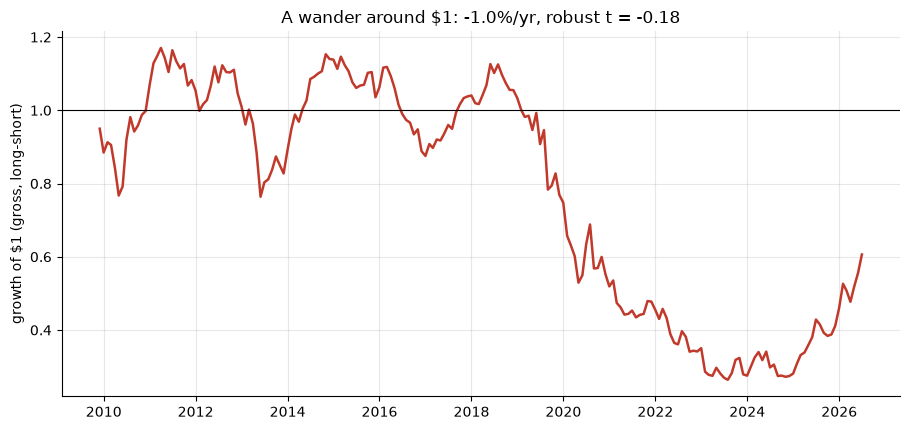

long-short: -1.0%/yr gross, Newey-West t = -0.18 (the bar is 2)


In [2]:
if HAVE_REAL:
    ls = st.calendar_ls(PX, EV, signal_col='divergence', n_buckets=3, min_names=6, staleness_days=200)
    s = st.calendar_ls_stats(ls)
    ann, tnw = s['ann_pct'], s['t_nw']
    cum = (1+ls['ls']).cumprod()
else:
    ann, tnw = R['ls_ann'], R['ls_t_nw']
    cum = None
fig, ax = plt.subplots(figsize=(9.2, 4.4))
if cum is not None:
    ax.plot(cum.index, cum.values, color=RED, lw=1.8)
    ax.axhline(1.0, c='k', lw=.8)
    ax.set_ylabel('growth of $1 (gross, long-short)')
    ax.set_title(f'A wander around $1: {ann:+.1f}%/yr, robust t = {tnw:+.2f}')
else:
    ax.text(.5,.5,'run with cache for the equity curve',ha='center'); ax.set_axis_off()
plt.tight_layout(); plt.show()
print(f'long-short: {ann:+.1f}%/yr gross, Newey-West t = {tnw:+.2f} (the bar is 2)')

There's no edge here to get excited about. The long-short drifts sideways around \$1, ends up **-1.0%/yr** (the *wrong* sign for the claim), and the robust *t*-statistic is **-0.18** — a rounding error away from zero. Worse, it isn't even stable: tweak how long a filing stays 'fresh' and the sign flips.

**The tell:** if the signal really sorted returns, the middle third should sit between the top and bottom. It doesn't — the thirds are jumbled.

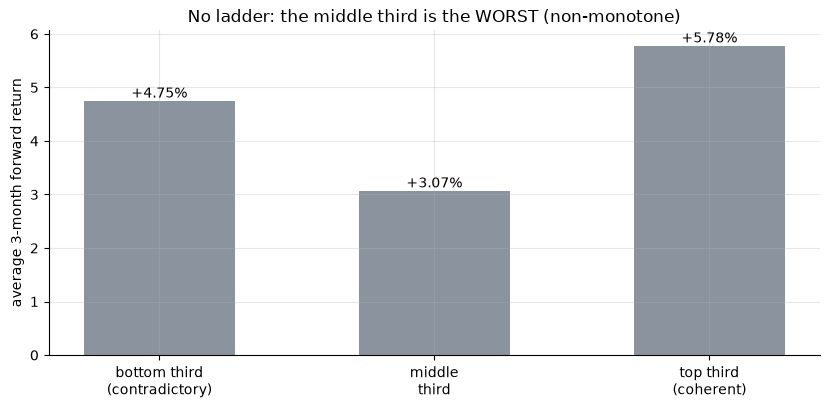

3-month forward return by divergence third (low->high): ['+4.75%', '+3.07%', '+5.78%']


In [3]:
if HAVE_REAL:
    fr = st.event_drift_frame(PX, EV, horizon=63)
    mono = st.bucket_means(fr, 3)*100
else:
    mono = np.array(R['mono63'])
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.bar(['bottom third\n(contradictory)','middle\nthird','top third\n(coherent)'], mono,
       color=[GREY, GREY, GREY], width=.55)
for i,v in enumerate(mono): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('average 3-month forward return')
ax.set_title('No ladder: the middle third is the WORST (non-monotone)')
plt.tight_layout(); plt.show()
print('3-month forward return by divergence third (low->high):', [f'{v:+.2f}%' for v in mono])

No staircase — the *middle* third (+3.07%) actually underperforms both the bottom (+4.75%) and the top (+5.78%). That's the fingerprint of noise, not a signal. A real cross-sectional edge lines the thirds up in order; this one scrambles them.

**Maybe the return doesn't move but the *fundamentals* do?** Abarbanell–Bushee's own logic says the contradictory names should suffer a later margin markdown. Let's line up today's divergence against *next year's* change in gross margin.

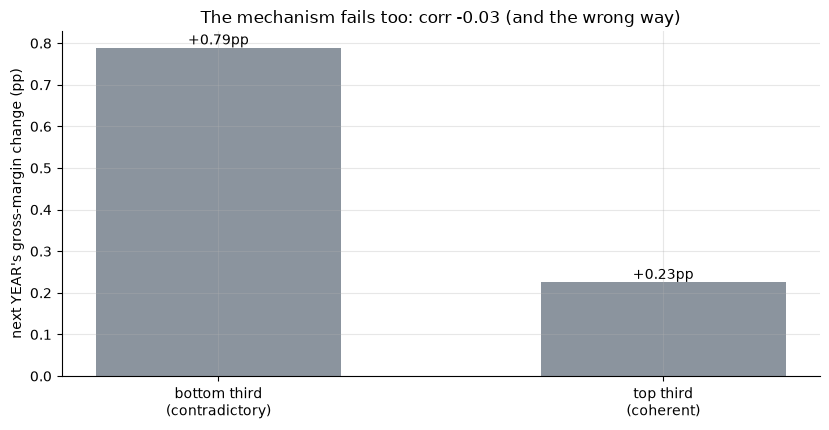

next-year margin change: coherent third +0.23pp vs contradictory third +0.79pp -> spread -0.56 pp, correlation -0.03


In [4]:
if HAVE_REAL:
    q = st.leads_margin(EV)
    top, bot, corr = q['top_margin']*100, q['bot_margin']*100, q['corr']
else:
    top, bot, corr = R['lm_top'], R['lm_bot'], R['lm_corr']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['bottom third\n(contradictory)','top third\n(coherent)'], [bot, top],
       color=[GREY, GREY], width=.55)
for i,v in enumerate([bot, top]): ax.annotate(f'{v:+.2f}pp',(i,v),ha='center',va='bottom')
ax.set_ylabel("next YEAR's gross-margin change (pp)")
ax.set_title(f'The mechanism fails too: corr {corr:+.2f} (and the wrong way)')
plt.tight_layout(); plt.show()
print(f'next-year margin change: coherent third {top:+.2f}pp vs contradictory third {bot:+.2f}pp '
      f'-> spread {top-bot:+.2f} pp, correlation {corr:+.2f}')

Flat, and if anything backwards: the 'contradictory' names go on to post a *slightly larger* margin gain (spread **-0.56 pp**, correlation **-0.03**). This is the opposite of the deferred-revenue study ([798](../../798-deferred-revenue-signal/)), where the accounting lead was bulletproof even though the stock didn't follow. Here **neither** the returns **nor** the fundamentals cooperate. Gross margins simply mean-revert, and a one-quarter 'contradiction' tells you nothing durable about where they head next.

## 5 · The verdict

- **Signal (returns) — None.** The long-short is a wrong-signed null (robust *t* = -0.18), sign-unstable across eras, with a non-monotone, placebo-insignificant event drift. Nothing to certify.
- **Leads the fundamentals? — No.** Correlation -0.03 with next year's margin change; the mechanism is absent.
- **Tradability — Mirage.** Negative before costs; costs only make it worse.

> The honest one-liner: *a contradiction you can spot in a 10-Q is not a secret, and on this tape it isn't even true.*

## 6 · Going further 🚪

- **Where an edge might still hide.** Not in the *level* of a public divergence, but perhaps in the *surprise* — inventory or margin moves versus a seasonal expectation — or in narrower, more homogeneous sub-industries where inventory means the same thing across names. The fused signal on a mixed basket is the version that fails here.
- **The coverage caveat is real.** The quarterly-span filter drops fiscal-Q4 figures and the cross-section averages ≈17–20 names; a deeper, industry-matched panel might sharpen the test — though a flat event drift across ~950 pooled events makes a hidden edge unlikely.
- **Sibling studies:** [529-inventory-growth](../../529-inventory-growth/) (inventory growth *level*), [854-cash-conversion-cycle](../../854-cash-conversion-cycle/) (working-capital cycle), [122-gross-profitability](../../122-gross-profitability/) (gross profits ÷ assets), [231-sloan-accruals](../../231-sloan-accruals/) (total accruals). See [docs/references.md](docs/references.md) for the exact dedup.

*Think the alpha is in the surprise, not the level, or inside one clean industry? Build it, show a certifiable net spread on the size you'd actually run — then we'll talk.*